In [1]:
import networkx as nx

from pyboolnet.external.bnet2primes import bnet_text2primes
from pyboolnet.prime_implicants import percolate
from pyboolnet.file_exchange import primes2bnet
from pyboolnet.interaction_graphs import primes2igraph

In [2]:
bnet="""
CD28, APC
FOXP3, (!FOXP3 & NFAT & !STAT1 & !STAT3 & STAT5 & SMAD3) | (!FOXP3 & NFAT & !STAT1 & STAT3 & STAT5 & SMAD3 & !RORGT) | (FOXP3 & NFAT & STAT5)
GATA3, (!TBET & !GATA3 & STAT6) | (!TBET & GATA3)
IFNBR, IFNB_e
IFNG, (!TBET & !FOXP3 & NFAT & !STAT3 & STAT4 & proliferation) | (TBET & !FOXP3 & NFAT & !STAT3 & !STAT4 & RUNX3 & proliferation) | (TBET & !FOXP3 & NFAT & !STAT3 & STAT4 & proliferation)
IFNGR, (!IFNG_e & IFNG) | IFNG_e 
IKB, !TCR
IL10, (!GATA3 & NFAT & STAT3 & proliferation) | (GATA3 & NFAT & proliferation)
IL10R, (!IL10_e & IL10) | IL10_e 
IL12R, IL12_e & IL12RB1_2 & IL12RB2
IL12RB1_2,  IRF1
IL12RB2, !STAT6
IL15R, IL15_e 
IL17, !FOXP3 & NFAT & !STAT1 & STAT3 & !STAT5 & !STAT6 & proliferation & NFKB & RORGT
IL2, (!TBET & !FOXP3 & !NFAT & !STAT5 & NFKB) | (!TBET & !FOXP3 & !NFAT & STAT5 & !STAT6 & NFKB) | (!TBET & !FOXP3 & NFAT & !STAT5) | (!TBET & !FOXP3 & NFAT & STAT5 & !STAT6) | (!TBET & FOXP3 & !STAT5 & NFKB) | (!TBET & FOXP3 & STAT5 & !STAT6 & NFKB) | (TBET & !FOXP3 & NFAT & !STAT5 & NFKB) | (TBET & !FOXP3 & NFAT & STAT5 & !STAT6 & NFKB)
IL21, NFAT & STAT3 & proliferation
IL21R, (!IL21_e & IL21) | IL21_e 
IL23, NFAT & STAT3 & proliferation
IL23R, (!IL23_e & IL23 & STAT3 & RORGT) | (IL23_e & STAT3 & RORGT)
IL27R, IL27_e
IL2RA, (!FOXP3 & NFAT & !STAT5 & !SMAD3 & NFKB) | (!FOXP3 & NFAT & !STAT5 & SMAD3) | (!FOXP3 & NFAT & STAT5) | (FOXP3 & NFAT)
IL2R, (!IL2_e & !IL2R & IL2) | (!IL2_e & IL2R & !IL2R_2 & IL2) | (!IL2_e & IL2R & IL2R_2) | (IL2_e & !IL2R) | (IL2_e & IL2R & !IL2R_2 ) | (IL2_e & IL2R & IL2R_2)
IL2R_2, (!IL2_e & IL2R & IL2RA & IL2) | (IL2_e & IL2R & IL2RA)
IL4, (!TBET & GATA3 & !FOXP3 & NFAT & !IRF1 & proliferation) | (TBET & GATA3 & !FOXP3 & NFAT & !IRF1 & !RUNX3 & proliferation)
IL4RA_2, STAT5 & STAT5_2
IL4R, (!IL4_e & !IL4R & IL4) | (!IL4_e & !IL4R_2 & IL4) | (!IL4_e & IL4R & IL4R_2) | (IL4_e & !IL4R ) | (IL4_e & IL4R & !IL4R_2 ) | (IL4_e & IL4R & IL4R_2)
IL4R_2, (!IL4_e & IL4R & IL4RA_2 & IL4) | (IL4_e & IL4R & IL4RA_2)
IL6R, IL6_e
IRF1, STAT1
NFAT, CD28 & TCR
NFKB, !FOXP3 & !IKB
RORGT, (!TGFBR & STAT3 & RORGT) | (TGFBR & !STAT3 & RORGT) | (TGFBR & STAT3)
RUNX3, TBET
SMAD3, TGFBR
STAT1, (!IFNBR & !IFNGR & IL27R) | (!IFNBR & IFNGR) | IFNBR
STAT3, (!IL6R & !IL10R & !IL21R & !IL23R & IL27R) | (!IL6R & !IL10R & !IL21R & IL23R) | (!IL6R & !IL10R & IL21R) | (!IL6R & IL10R) | IL6R
STAT4, IL12R & !GATA3
STAT5, (!IL2R & !IL4R & !IL15R & STAT5 & STAT5_2) | (!IL2R & !IL4R & IL15R) | (!IL2R & IL4R) | IL2R
STAT5_2, (!IL2R & IL4R & IL4R_2 & STAT5) | (IL2R & !IL2R_2 & IL4R & IL4R_2 & STAT5) | (IL2R & IL2R_2 & STAT5)
STAT6, IL4R
TBET, (!TBET & !GATA3 & STAT1) | (TBET & !GATA3)
TCR, APC
TGFB, FOXP3 & NFAT & proliferation
TGFBR, (!TGFB_e & TGFB) | TGFB_e
proliferation, (!STAT5 & proliferation) | (STAT5 & !STAT5_2 & proliferation) | (STAT5 & STAT5_2)
"""

In [3]:
# import bnet
primes = bnet_text2primes(bnet)

# Percolate constant nodes
percolated_primes = percolate(primes, remove_constants=True, copy=True)
percolated_bnet = primes2bnet(percolated_primes)

print(percolated_bnet)

APC,             APC
IFNB_e,          IFNB_e
IFNG_e,          IFNG_e
IL10_e,          IL10_e
IL12_e,          IL12_e
IL15_e,          IL15_e
IL21_e,          IL21_e
IL23_e,          IL23_e
IL27_e,          IL27_e
IL2_e,           IL2_e
IL4_e,           IL4_e
IL6_e,           IL6_e
TGFB_e,          TGFB_e

CD28,            APC
FOXP3,           NFAT & SMAD3 & !STAT1 & !STAT3 & STAT5 | NFAT & !RORGT & SMAD3 & !STAT1 & STAT5 | FOXP3 & NFAT & STAT5
GATA3,           STAT6 & !TBET | GATA3 & !TBET
IFNBR,           IFNB_e
IFNG,            !FOXP3 & NFAT & RUNX3 & !STAT3 & TBET & proliferation | !FOXP3 & NFAT & !STAT3 & STAT4 & proliferation
IFNGR,           IFNG_e | IFNG
IKB,             !TCR
IL10,            NFAT & STAT3 & proliferation | GATA3 & NFAT & proliferation
IL10R,           IL10_e | IL10
IL12R,           IL12RB1_2 & IL12RB2 & IL12_e
IL12RB1_2,       IRF1
IL12RB2,         !STAT6
IL15R,           IL15_e
IL2,             !FOXP3 & NFAT & !STAT6 & !TBET | !FOXP3 & NFAT & !STAT5 & !TBET | !

In [4]:
ig = primes2igraph(percolated_primes)

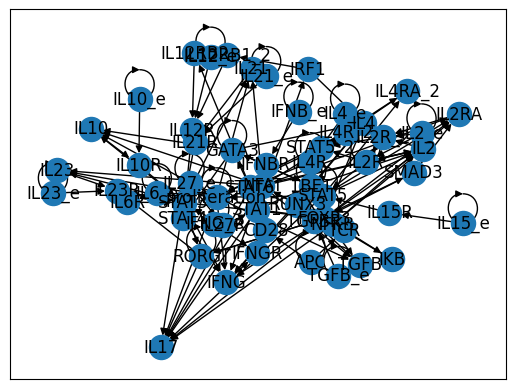

In [5]:
nx.draw_networkx(ig, arrows=True)

In [6]:
def see_attributes(G):

    print("Graph attrs:", G.graph)

    node, node_attrs = next(iter(G.nodes(data=True)))
    print("\nFirst node:", node)
    print(node_attrs)

    u, v, edge_attrs = next(iter(G.edges(data=True)))
    print("\nFirst edge:", (u, v))
    print(edge_attrs)

In [7]:
see_attributes(ig)

Graph attrs: {'node': {'style': 'filled', 'shape': 'circle', 'fixedsize': 'true', 'width': '1.0172413793103448', 'color': 'none', 'fillcolor': 'gray95'}, 'edge': {}, 'subgraphs': []}

First node: APC
{}

First edge: ('APC', 'APC')
{'sign': {1}}


In [8]:
import json
import numpy as np
import networkx as nx


def _sanitize_attrs(attrs: dict):
    """Convert GraphML-incompatible attribute types to JSON strings."""
    for k, v in list(attrs.items()):

        if isinstance(v, np.ndarray):
            v = v.tolist()

        elif isinstance(v, set):
            v = sorted(list(v))  # deterministic + GraphML-safe

        elif isinstance(v, (list, tuple)):
            v = list(v)

        elif isinstance(v, dict):
            v = v

        # recursively ensure everything becomes JSON-serializable scalar or string
        if isinstance(v, (list, dict)):
            attrs[k] = json.dumps(v)
        else:
            attrs[k] = v


def export_graphml(G: nx.DiGraph, path: str):
    G = G.copy()

    _sanitize_attrs(G.graph)

    for node, attrs in G.nodes(data=True):
        attrs.setdefault("label", str(node))
        _sanitize_attrs(attrs)

    for u, v, attrs in G.edges(data=True):
        attrs.setdefault("label", f"{u}->{v}")
        _sanitize_attrs(attrs)

    nx.write_graphml(G, path)

In [10]:
contraint_edges = [('APC', 'CD28'), ('NFAT', 'FOXP3'), ('RORGT', 'FOXP3'), ('SMAD3', 'FOXP3'), ('STAT5', 'FOXP3'), ('STAT6', 'GATA3'), ('IFNB_e', 'IFNBR'), ('RUNX3', 'IFNG'), ('TBET', 'IFNG'), ('IFNG', 'IFNGR'), ('IFNG_e', 'IFNGR'), ('TCR', 'IKB'), ('IL10', 'IL10R'), ('IL10_e', 'IL10R'), ('IL12RB2', 'IL12R'), ('IL12_e', 'IL12R'), ('IL15_e', 'IL15R'), ('STAT3', 'IL17'), ('STAT5', 'IL17'), ('NFKB', 'IL2'), ('STAT3', 'IL21'), ('IL21', 'IL21R'), ('IL21_e', 'IL21R'), ('STAT3', 'IL23'), ('IL23', 'IL23R'), ('IL23_e', 'IL23R'), ('RORGT', 'IL23R'), ('STAT3', 'IL23R'), ('IL27_e', 'IL27R'), ('IL2', 'IL2R'), ('IL2_e', 'IL2R'), ('FOXP3', 'IL2RA'), ('NFAT', 'IL2RA'), ('NFKB', 'IL2RA'), ('STAT5', 'IL2RA'), ('GATA3', 'IL4'), ('NFAT', 'IL4'), ('RUNX3', 'IL4'), ('TBET', 'IL4'), ('IL4', 'IL4R'), ('IL4_e', 'IL4R'), ('IL6_e', 'IL6R'), ('CD28', 'NFAT'), ('TCR', 'NFAT'), ('FOXP3', 'NFKB'), ('IKB', 'NFKB'), ('STAT3', 'RORGT'), ('IFNBR', 'STAT1'), ('IFNGR', 'STAT1'), ('IL27R', 'STAT1'), ('IL10R', 'STAT3'), ('IL23R', 'STAT3'), ('IL27R', 'STAT3'), ('IL6R', 'STAT3'), ('IL2R', 'STAT5'), ('STAT1', 'TBET'), ('TBET', 'TBET'), ('TGFB', 'TGFBR'), ('TGFB_e', 'TGFBR'), ('RORGT', 'IL17'), ('NFAT', 'IL2'), ('IL2R', 'IL2R_2'), ('IL4R', 'IL4R_2'), ('STAT5', 'STAT5_2'), ('APC', 'TCR')]
consensus_edges = [('APC', 'APC'), ('FOXP3', 'IFNG'), ('FOXP3', 'IL4'), ('GATA3', 'GATA3'), ('GATA3', 'TBET'), ('IFNB_e', 'IFNB_e'), ('IFNG_e', 'IFNG_e'), ('IL10_e', 'IL10_e'), ('IL12_e', 'IL12_e'), ('IL15_e', 'IL15_e'), ('IL21_e', 'IL21_e'), ('IL23_e', 'IL23_e'), ('IL27_e', 'IL27_e'), ('IL2_e', 'IL2_e'), ('IL4R', 'STAT6'), ('IL4_e', 'IL4_e'), ('IL6_e', 'IL6_e'), ('IRF1', 'IL12RB1_2'), ('IRF1', 'IL4'), ('STAT1', 'IRF1'), ('STAT3', 'IFNG'), ('STAT6', 'IL12RB2'), ('TBET', 'RUNX3'), ('TGFBR', 'SMAD3'), ('TGFB_e', 'TGFB_e'), ('proliferation', 'IFNG')]

In [11]:
for u, v in consensus_edges:
    if ig.has_edge(u, v):
        ig.edges[u, v]["type"] = "consensus"

for u, v in contraint_edges:
    if ig.has_edge(u, v):
        ig.edges[u, v]["type"] = "constraint"

In [12]:
export_graphml(ig, "interaction.graphml")